# DLR - Week03: Working with Sequential Data

In the lecture, we got familiar with recurrent neural networks and transformer.

Now, let's try to apply these new techniques in practice. The seminar is created around the [SketchRNN](https://arxiv.org/abs/1704.03477) paper.

Drawing sketches can be considered as sequential dat. Indeed, at each timestep $t$

1. the pen is either on the screen (drawing mode) or up (change of spatial position or end of drawing)
2. the pen is located on a $(x, y)$ position on a canvas

When an artist draws, the pen changes its position by $(\Delta x, \Delta y$) and can be in three possible positions:

1. $p_1$ -- the pen touches the paper and it is in the process of drawing

2. $p_2$ -- the pen is going to be lifted after that timestep and moved somewhere without drawing

3. $p_3$ -- the drawing is ended

So at each timestep $t$, we have vector $(\Delta x_t, \Delta y_t, p_{1,t}, p_{2,t}, p_{3,t})$

Let's look at an example. We will use the [Quick Draw](https://github.com/googlecreativelab/quickdraw-dataset) dataset of sketches:

![img](https://github.com/googlecreativelab/quickdraw-dataset/raw/master/preview.jpg)

We will use with the SketchRNN dataset partitions in the `.npz` format. Each `.npz` file corresponds to a certain sketch category and contains 3 splits: train, validation, and test.

 Each element in the dataset is in the stroke-3 format ($p_2$ and $p_3$ are merged, so we have a single binary -- pen is up or down). We will convert it to stroke-5 format for consistency with the SketchRNN paper.

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 1) Download 1 category .npz
# ----------------------------
CATEGORY = "cat"  # e.g. "alarm_clock", "airplane", "bicycle", "face", ...
DATA_DIR = "data/sketchrnn_data"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/sketchrnn"
FNAME = f"{CATEGORY}.npz"
FPATH = os.path.join(DATA_DIR, FNAME)

if not os.path.exists(FPATH):
    !wget -q -O "{FPATH}" "{BASE_URL}/{FNAME}"
    print("Downloaded:", FPATH)
else:
    print("Already exists:", FPATH)

Downloaded: data/sketchrnn_data/cat.npz


We downloaded the data, now let's take the splits

In [ ]:
# ----------------------------
# 2) Load (Python2 pickle fix)
# ----------------------------
data = np.load(FPATH, allow_pickle=True, encoding="latin1")
train_seqs = data["train"]
valid_seqs = data["valid"]
test_seqs  = data["test"]

In [ ]:
print(len(train_seqs), len(valid_seqs), len(test_seqs))

70000 2500 2500


Let's look at one element

In [ ]:
train_seqs[0]

array([[  -3,   -8,    0],
       [   2,  -38,    0],
       [  14,    8,    0],
       [  20,   26,    0],
       [  22,  -14,    0],
       [  10,   -3,    0],
       [  51,    0,    0],
       [  31,   -5,    0],
       [  12,    3,    0],
       [   5,   -6,    0],
       [   7,  -21,    0],
       [   5,   -3,    0],
       [   9,   31,    0],
       [   0,   91,    0],
       [  -2,    8,    0],
       [ -12,   11,    0],
       [ -44,   22,    0],
       [ -51,    2,    0],
       [ -17,   -4,    0],
       [ -11,   -5,    0],
       [ -42,  -31,    0],
       [ -11,  -13,    0],
       [  -5,  -15,    0],
       [   0,  -15,    0],
       [   3,  -14,    0],
       [   9,  -18,    1],
       [  44,   41,    0],
       [   8,   24,    1],
       [  83,  -49,    0],
       [   2,   36,    0],
       [   5,    9,    1],
       [ -74,   15,    0],
       [  43,   -3,    1],
       [ -18,    0,    0],
       [  -1,   36,    1],
       [ -42, -181,    0],
       [   1,  -36,    0],
 

We see that it is in stroke3 format. Let's convert it to stroke 5. If we see 0, the pen is down, otherwise it is up. So

0 -- $p_1=1$. 1 -- $p_2 = 1$ if the element is not last, otherwise, $p_3=1$.

In [ ]:
def stroke3_to_stroke5(seq):
    """
    Dataset: seq is [T,3] = (dx, dy, pen_up)
    Convert to    [T,5] = (dx, dy, p1, p2, p3)
      p1 = pen_down
      p2 = pen_up
      p3 = EOS
    """
    seq = np.asarray(seq).astype(np.float32)
    if seq.ndim != 2 or seq.shape[1] != 3:
        raise ValueError(f"Expected [T,3], got {seq.shape}")

    T = seq.shape[0]
    dx = seq[:, 0]
    dy = seq[:, 1]
    pen_up = seq[:, 2]  # IMPORTANT: pen_up

    out = np.zeros((T, 5), dtype=np.float32)
    out[:, 0] = dx
    out[:, 1] = dy

    # pen_down = 1 - pen_up
    out[:, 2] = (1.0 - pen_up > 0.5).astype(np.float32)  # p1
    out[:, 3] = (pen_up > 0.5).astype(np.float32)        # p2
    out[:, 4] = 0.0                                      # p3

    # EOS at last step
    out[-1, 2:5] = 0.0
    out[-1, 4] = 1.0

    return out

Now let's visualize our element from the dataset

In [ ]:
elem = train_seqs[0]
elem = stroke3_to_stroke5(elem)
elem

array([[  -3.,   -8.,    1.,    0.,    0.],
       [   2.,  -38.,    1.,    0.,    0.],
       [  14.,    8.,    1.,    0.,    0.],
       [  20.,   26.,    1.,    0.,    0.],
       [  22.,  -14.,    1.,    0.,    0.],
       [  10.,   -3.,    1.,    0.,    0.],
       [  51.,    0.,    1.,    0.,    0.],
       [  31.,   -5.,    1.,    0.,    0.],
       [  12.,    3.,    1.,    0.,    0.],
       [   5.,   -6.,    1.,    0.,    0.],
       [   7.,  -21.,    1.,    0.,    0.],
       [   5.,   -3.,    1.,    0.,    0.],
       [   9.,   31.,    1.,    0.,    0.],
       [   0.,   91.,    1.,    0.,    0.],
       [  -2.,    8.,    1.,    0.,    0.],
       [ -12.,   11.,    1.,    0.,    0.],
       [ -44.,   22.,    1.,    0.,    0.],
       [ -51.,    2.,    1.,    0.,    0.],
       [ -17.,   -4.,    1.,    0.,    0.],
       [ -11.,   -5.,    1.,    0.,    0.],
       [ -42.,  -31.,    1.,    0.,    0.],
       [ -11.,  -13.,    1.,    0.,    0.],
       [  -5.,  -15.,    1.,    

We will convert strokes to lines. If pen is down, we are plotting points. If pen is up, we finished or we are moving the pen without having a line:

**Note**: code below always does comparison with $0.5$ because of floating points instead of explicit comparison with $1.0$.

In [ ]:
import torch


def stroke5_to_lines(strokes):
    if isinstance(strokes, torch.Tensor):
        strokes = strokes.detach().cpu().numpy()

    x, y = 0.0, 0.0
    lines = []
    current = []

    for dx, dy, p1, p2, p3 in strokes:
        x += float(dx)
        y += float(dy)

        if p1 > 0.5:  # pen down
            current.append((x, y))

        if (p2 > 0.5) or (p3 > 0.5):  # pen up or EOS closes stroke
            if len(current) > 0:
                lines.append(current)
                current = []

        if p3 > 0.5:
            break

    if len(current) > 0:
        lines.append(current)

    return lines

Now, using matplotlib, we can draw these lines. We provide 2 scripts: (1) draw everything at the same time and (2) look how sketch evolves over time

In [ ]:
# plotting stuff
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina' # makes the quality higher

import seaborn as sns
sns.set_style("whitegrid") # improves the quality of matplotlib images and adds grid

In [ ]:
def plot_sketch(strokes):
    if isinstance(strokes, torch.Tensor):
        strokes = strokes.detach().cpu().numpy()
    lines = stroke5_to_lines(strokes)

    plt.figure(figsize=(4,4))
    for line in lines:
        xs = [p[0] for p in line]
        ys = [p[1] for p in line]
        plt.plot(xs, -np.array(ys))

    plt.axis("off")
    plt.gca().set_aspect("equal")
    plt.show()


In [ ]:
from IPython.display import clear_output
import time


def animate_sketch(strokes, delay=0.03):
    if isinstance(strokes, torch.Tensor):
        strokes = strokes.detach().cpu().numpy()

    x, y = 0.0, 0.0
    xs, ys = [], []

    for dx, dy, p1, p2, p3 in strokes:
        x += float(dx)
        y += float(dy)

        if p1 > 0.5:
            xs.append(x)
            ys.append(-y)

        # IMPORTANT: break the polyline when pen lifts (or EOS)
        if (p2 > 0.5) or (p3 > 0.5):
            xs.append(np.nan)
            ys.append(np.nan)

        clear_output(wait=True)
        plt.figure(figsize=(4,4))
        plt.plot(xs, ys)
        plt.axis("off")
        plt.gca().set_aspect("equal")
        plt.show()

        time.sleep(delay)

        if p3 > 0.5:
            break


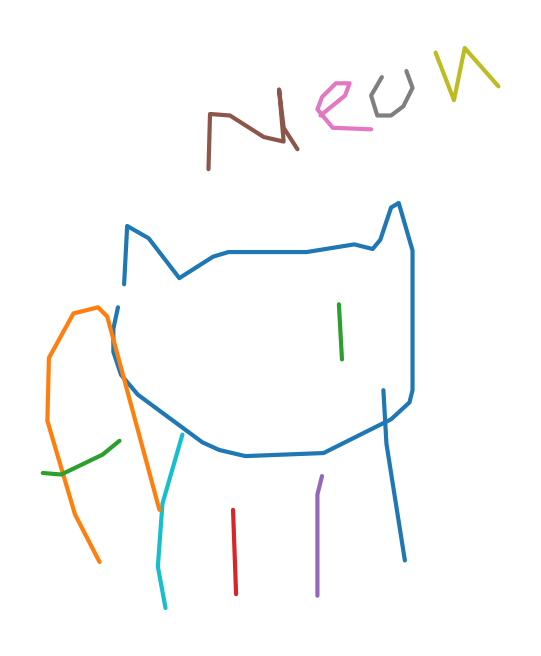

In [ ]:
plot_sketch(elem)

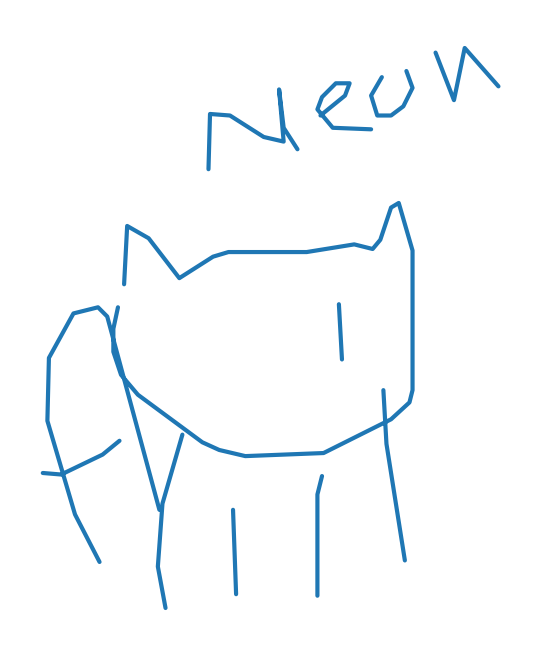

In [ ]:
animate_sketch(elem)

Cool! Now, let's think what we can do with this.


One example is to do Generation. Let's train a model to draw!!!

Since the data is sequential, we are in a classic Autoregressive design setup. We have a sequence $S[n]$ and we want to learn to predict $S[n+1]$.


Hence, we need to resolve two issues:

1. What is a **starting point**?
2. What is a desired label and how to train?

For the first question, a straighforward way would be to start at $S[0] := (0, 0, 0, 1, 0)$ -- the pen is up and nothing is happending. We are just starting drawing.

**Note:** for conditional generation, one may make $S[0]$ category-dependent, so the model knows which category to generate based on it. Furthermore, for the RNN case, we can make the initial memory hidden state $h_0$ dependent on the class, while keeping the $S[0]$ the same. But let's focus on unconditional generation for today with a single category.

For the second question -- we will use teacher forcing technique discussed in the lecture. That is, we will train on ($S[0], S[1], ..., S[n-1]; S[1], S[2], ..., S[n])$ pairs (we shift the sequence to the right, so $S[1]$ is predicted based on $S[0]$, $S[2]$ based on $S[1]$ and $S[0]$, etc.).

Let's write it in PyTorch

In [ ]:
START_TOKEN = np.array([0.0, 0.0, 0.0, 1.0, 0.0], dtype=np.float32)


class SketchRNNStroke5Shifted(Dataset):
    def __init__(self, sequences, max_len=150):
        self.sequences = sequences
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        y = stroke3_to_stroke5(self.sequences[idx])  # target, [T,5]

        # truncate (keep EOS at end)
        if self.max_len is not None and len(y) > self.max_len:
            y = y[: self.max_len].copy()
            y[-1, 2:5] = 0.0
            y[-1, 4] = 1.0

        # build x by shifting and prepending START
        x = np.vstack([START_TOKEN[None, :], y[:-1]])  # [T,5]

        return torch.from_numpy(x), torch.from_numpy(y)  # both [T,5]



In [ ]:
MAX_LEN = 150

train_ds = SketchRNNStroke5Shifted(train_seqs, max_len=MAX_LEN)
valid_ds = SketchRNNStroke5Shifted(valid_seqs, max_len=MAX_LEN)

But, we have an issue:

In [ ]:
train_ds[0][0].shape, train_ds[1][0].shape

(torch.Size([96, 5]), torch.Size([81, 5]))

Elements are of the different size. It is very common, especially for the sequential data.

It is problematic, because `PyTorch` is able to process only matrices of "fixed" shape (each row is of the same length). So, we cannot do batch-processing.


**Fix**: padding. Let's pad short sequences with zeros so they have the same length as the longest sequence in a batch. To do so, we use `collate_fn` argument of `DataLoader`

```python
def collate_fn(dataset_list: list[(Dataset Class output type)]):
    """
    Args:
      dataset_list: list of elements from __getitem__ of the Dataset object
    Returns:
      batch
    """
    ...
```

We can do padding manually. One may also consider using `torch.nn.utils.rnn.pad_sequence` function (see [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html)).

In [ ]:

def pad_collate_xy(batch): # list of elements from dataset getitem
    """
    batch: list of (x[T,5], y[T,5])
    Returns:
      x_pad: [B,Tmax,5]
      y_pad: [B,Tmax,5]
      lengths: [B]
      mask: [B,Tmax]
    """
    xs, ys = zip(*batch)
    # get length to recall what is padded and what is not
    lengths = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)
    Tmax = int(lengths.max())
    B = len(xs)

    x_pad = torch.zeros((B, Tmax, 5), dtype=torch.float32)
    y_pad = torch.zeros((B, Tmax, 5), dtype=torch.float32)

    # get mask to avoid calculating loss, etc. on padded elements
    mask = torch.zeros((B, Tmax), dtype=torch.bool)

    for i, (x, y) in enumerate(zip(xs, ys)):
        T = x.shape[0]
        x_pad[i, :T] = x
        y_pad[i, :T] = y
        mask[i, :T] = True

    return x_pad, y_pad, lengths, mask

BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, collate_fn=pad_collate_xy
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, collate_fn=pad_collate_xy
)

In [ ]:
# --------------------------------------------
# 3) Sanity checks
# --------------------------------------------
x, y, lengths, mask = next(iter(train_loader))
print("Batch x:", x.shape, "lengths:", lengths.shape, "mask:", mask.shape)


Batch x: torch.Size([64, 124, 5]) lengths: torch.Size([64]) mask: torch.Size([64, 124])


Awesome! Now let's create a model that will draw for us. Actually, we can just use an LSTM without any additional tricks.

For each timestep $t$, we need to learn to predict $S[t+1]$ from the hidden state of the LSTM $h_t$ (which accumulates information from $S[0],...,S[t]$.

To do so, we need to model our data:

1. $p(\Delta x, \Delta y)$ can be modelled as a Gaussian Mixture Model (GMM). We use a Mixture, because the direction of a stroke is not limited and a single Gaussian would not be enough.
$$
p(\Delta x, \Delta y) = \sum_{j=1}^{M} \pi_j \mathcal{N}(\Delta x, \Delta y | \mu_{x, j}, \mu_{y, j}, \sigma_{x, j}, \sigma_{y, j}, ρ_{xy, j}), \qquad \sum_{j=1}^{M} \pi_j = 1
$$
  Our LSTM will need to predict these $(\mu_x, \mu_y, \sigma_x, \sigma_y, ρ_{xy})$ for each $j$ and $\pi_j$ itself. The $(\mu_x, \mu_y, \sigma_x, \sigma_y, ρ_{xy})$ can be taken directly from the output of the DNN, but we additionaly use $\sigma = \exp (\sigma_{\text{predicted}})$ and $\rho_{xy} = \text{tanh}(\rho_{xy, \text{predicted}})$ to ensure the standard deviation is non-negative and the correlation is between -1 and 1. To ensure the property on $\pi$, we will take the result after `SoftMax`.

  2. Similarly to $\pi$, we can see $p_1, p_2, p_3$ prediction as a categorical distribution that we sample from a predicted distribution $(q_1, q_2, q_3)$, where $q$ is taken after `SoftMax`.


**Note**. It is common for generative methods, to use a **temperature** for distributions. Temperature smoothes the distribution or makes it pickear. This is done inside `SoftMax`: $\text{SoftMax}\left(\frac{z}{\tau}\right)$.

$\tau < 1$ sharper distribution, lower entropy, more deterministic generations

$\tau > 1$: flatter distribution, higher entropy, more diverse generations

Lower temperature often produces cleaner, more realistic samples by emphasizing high-probability modes, but it reduces diversity.
Temperature does not improve the model itself — it only modifies the sampling behavior.


What about the loss function? We want to maximize probability of a sketch under our model. For autoregressive generation we get

$$
p(\text{sketch}) = p(S[0],...,S[n]) = \prod_{t=0}^{t=n}p(s_t|s_{< t})
$$

But optimizing a product is hard due to numerical and computational issues. Hence, we use an equivalent log-version:

$$
\log p(\text{sketch}) = \sum_{t=0}^{t=n}\log p(s_t|s_{< t})
$$

We want to maximize it, but for losses, we usually want to do minimization. So let's add a minus:

$$
\mathcal{L}_{\text{NLL}} = -\sum_{t=0}^{t=n}\log p(s_t|s_{< t})
$$

Let's write the NLL loss in terms of our GMM:

$$
p(s_t \mid s_{<t})
=
p(\Delta x_t, \Delta y_t \mid s_{<t})
\cdot
p(\mathbf{p}_t \mid s_{<t}),
\qquad
\mathbf{p}_t \in \{(1,0,0),(0,1,0),(0,0,1)\}.
$$

Hence, for our timestep the NLL loss is:
$$
\mathcal{L}_t
=
-\log p(\Delta x_t, \Delta y_t \mid s_{<t})
-\log p(\mathbf{p}_t \mid s_{<t}).
$$

Then,

$$
p(\Delta x_t, \Delta y_t \mid s_{<t})
=
\sum_{j=1}^{M}
\pi_{t,j}\;
\mathcal{N}\!\left(
\Delta x_t, \Delta y_t
\mid
\mu_{x,t,j}, \mu_{y,t,j},
\sigma_{x,t,j}, \sigma_{y,t,j},
\rho_{t,j}
\right),
\qquad
\sum_{j=1}^{M}\pi_{t,j}=1,\ \pi_{t,j}\ge 0.
$$

and, for $p_1, p_2, p_3$, the pen-state term is the negative log-likelihood of a categorical distribution (i.e., cross-entropy):

$$
p(\mathbf{p}_t \mid s_{<t})
=
\prod_{k=1}^{3} q_{t,k}^{\,p_{t,k}}
\quad\Longrightarrow\quad
\log p(\mathbf{p}_t \mid s_{<t})
=
\sum_{k=1}^{3} p_{t,k}\log q_{t,k}.
$$

Hence

$$
\mathcal{L}_t
=
-\log\left(
\sum_{j=1}^{M}
\pi_{t,j}\;
\mathcal{N}\!\left(
\Delta x_t, \Delta y_t
\mid
\mu_{x,t,j}, \mu_{y,t,j},
\sigma_{x,t,j}, \sigma_{y,t,j},
\rho_{t,j}
\right)
\right)
-\sum_{k=1}^{3} p_{t,k}\log q_{t,k}.
$$

**Final note**: for computation, we will need to compute the density of the normal distribution:

$$
\mathcal{N}(x, y \mid \mu_x, \mu_y, \sigma_x, \sigma_y, \rho)
=
\frac{1}{2\pi \sigma_x \sigma_y \sqrt{1-\rho^2}}
\exp
\left(
-
\frac{1}{2(1-\rho^2)}
\left[
\frac{(x-\mu_x)^2}{\sigma_x^2}
+
\frac{(y-\mu_y)^2}{\sigma_y^2}
-
\frac{2\rho (x-\mu_x)(y-\mu_y)}{\sigma_x \sigma_y}
\right]
\right)
$$

For numerical stability, we will compute $\log \left(\sum_j\pi_j\mathcal{N}_j\right)$ using log-sum-exp:

$$
\log \left(\sum_j\pi_j\mathcal{N}_j\right) = \log\left(\sum_je^{\log \pi_j + \log \mathcal{N}_j}\right)
$$

Now, we can code everything:

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Utils: bivariate Gaussian logpdf
# ----------------------------
def bivariate_gaussian_logpdf(x, y, mux, muy, sx, sy, rho, eps=1e-6):
    """
    x,y:    [B,T,1] or [B,T,K]
    mux...: [B,T,K]
    returns log N([x,y]; mean, cov) shape [B,T,K]
    """
    sx = torch.clamp(sx, min=eps)
    sy = torch.clamp(sy, min=eps)
    rho = torch.clamp(rho, min=-1+1e-5, max=1-1e-5)

    # normalize
    x_m = x - mux
    y_m = y - muy

    # z term
    z = (x_m / sx) ** 2 + (y_m / sy) ** 2 - 2 * rho * (x_m * y_m) / (sx * sy)
    denom = 2 * (1 - rho**2)

    log_norm = -torch.log(2 * math.pi * sx * sy * torch.sqrt(1 - rho**2) + eps)
    log_exp = -z / (denom + eps)
    return log_norm + log_exp


# ----------------------------
# SketchRNN Unconditional Decoder
# ----------------------------
class SketchRNNUncond(nn.Module):
    """
    Unconditional SketchRNN-style decoder:
      Input x: [B,T,5] (dx,dy,p1,p2,p3) (teacher forcing)
      Outputs:
        - mixture params for (dx,dy): pi, mu, sigma, rho
        - pen logits for (p1,p2,p3)
    """
    def __init__(self, hidden_size=256, num_layers=1, num_mixtures=20, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.M = num_mixtures

        self.rnn = nn.LSTM(
            input_size=5,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # MDN head for dx,dy: pi, mux, muy, log_sx, log_sy, rho
        # total per mixture: 6M
        self.mdn = nn.Linear(hidden_size, 6 * self.M)

        # Pen head for p1,p2,p3
        self.pen = nn.Linear(hidden_size, 3)

    def forward(self, x, hidden=None):
        """
        x: [B,T,5]
        hidden: optional (h0,c0)
        returns dict of params + hidden
        """
        h, hidden = self.rnn(x, hidden)  # h: [B,T,H]

        mdn_out = self.mdn(h)  # [B,T,6K]
        B, T, _ = mdn_out.shape
        M = self.M
        mdn_out = mdn_out.view(B, T, 6, M)

        # unpack
        logits_pi = mdn_out[:, :, 0, :]                 # [B,T,M]
        mux       = mdn_out[:, :, 1, :]                 # [B,T,M]
        muy       = mdn_out[:, :, 2, :]                 # [B,T,M]
        log_sx    = mdn_out[:, :, 3, :]                 # [B,T,M]
        log_sy    = mdn_out[:, :, 4, :]                 # [B,T,M]
        rho_raw   = mdn_out[:, :, 5, :]                 # [B,T,M]

        # constrain
        pi = F.softmax(logits_pi, dim=-1)               # [B,T,M]
        sx = torch.exp(log_sx)                          # [B,T,M]
        sy = torch.exp(log_sy)                          # [B,T,M]
        rho = torch.tanh(rho_raw)                       # [B,T,M]

        pen_logits = self.pen(h)                        # [B,T,3]

        return {
            "pi": pi,
            "logits_pi": logits_pi,
            "mux": mux,
            "muy": muy,
            "sx": sx,
            "sy": sy,
            "rho": rho,
            "pen_logits": pen_logits,
            "hidden": hidden,
        }


    @torch.no_grad()
    def sample(self, max_len=200, temperature=0.8, device=None, start_token=None):
        """
        Autoregressive sampling. Returns a tensor [T,5] stroke-5.
        """
        if device is None:
            device = next(self.parameters()).device

        if start_token is None:
            # (0,0, pen_down, pen_up, eos) = (0,0,0,1,0)
            start_token = torch.tensor([0.0, 0.0, 0.0, 1.0, 0.0], device=device)

        x_t = start_token.view(1, 1, 5)  # [1,1,5]
        hidden = None
        out = []

        for _ in range(max_len):
            params = self.forward(x_t, hidden=hidden)
            hidden = params["hidden"]

            # --- choose mixture component ---
            logits_pi = params["logits_pi"][0, 0] / max(temperature, 1e-6)  # [M]
            pi = F.softmax(logits_pi, dim=-1)
            m = torch.multinomial(pi, num_samples=1).item()

            mux = params["mux"][0, 0, m]
            muy = params["muy"][0, 0, m]
            sx  = params["sx"][0, 0, m] * math.sqrt(temperature)
            sy  = params["sy"][0, 0, m] * math.sqrt(temperature)
            rho = params["rho"][0, 0, m]

            # sample correlated gaussian
            u = torch.randn((), device=device)
            v = torch.randn((), device=device)
            dx = mux + sx * u
            dy = muy + sy * (rho * u + torch.sqrt(1 - rho**2 + 1e-6) * v)

            # --- pen state ---
            pen_logits = params["pen_logits"][0, 0] / max(temperature, 1e-6)  # [3]
            pen_probs = F.softmax(pen_logits, dim=-1)
            pen_idx = torch.multinomial(pen_probs, 1).item()  # 0,1,2

            p = torch.zeros(3, device=device)
            p[pen_idx] = 1.0

            step = torch.tensor([dx, dy, p[0], p[1], p[2]], device=device)
            out.append(step)

            # next input
            x_t = step.view(1, 1, 5)

            # stop if EOS
            if pen_idx == 2:
                break

        return torch.stack(out, dim=0)  # [T,5]


# ----------------------------
# Loss: MDN NLL + pen CE with mask
# ----------------------------
def sketchrnn_loss(params, y, mask, eps=1e-6):
    """
    params: dict from model.forward(x)
    y:    [B,T,5] target stroke-5
    mask: [B,T] boolean (True valid)
    returns scalar loss
    """
    # targets
    dx = y[:, :, 0:1]   # [B,T,1]
    dy = y[:, :, 1:1+1] # [B,T,1]
    pen_tgt = y[:, :, 2:5]  # [B,T,3]
    pen_idx = pen_tgt.argmax(dim=-1)  # [B,T]

    # --- MDN log-likelihood for dx,dy ---
    # compute log pdf under each component
    logpdf = bivariate_gaussian_logpdf(
        x=dx, y=dy,
        mux=params["mux"], muy=params["muy"],
        sx=params["sx"], sy=params["sy"],
        rho=params["rho"],
        eps=eps
    )  # [B,T,K]

    # mix with pi: log sum_k pi_k * N_k
    log_pi = F.log_softmax(params["logits_pi"], dim=-1)  # [B,T,K]
    log_mix = torch.logsumexp(log_pi + logpdf, dim=-1)   # [B,T]
    nll_xy = -log_mix                                     # [B,T]

    # --- pen cross-entropy ---
    pen_logits = params["pen_logits"]                    # [B,T,3]
    nll_pen = F.cross_entropy(
        pen_logits.reshape(-1, 3),
        pen_idx.reshape(-1),
        reduction="none"
    ).view_as(pen_idx)                                   # [B,T]

    # --- mask + average ---
    mask_f = mask.float()
    denom = mask_f.sum().clamp_min(1.0)

    loss = ((nll_xy + nll_pen) * mask_f).sum() / denom
    return loss

Now that we have everything, we just take the training loop from the previous seminar

In [ ]:
from tqdm.auto import tqdm
from IPython import display

def train_one_epoch_sketchrnn(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()

    avg_loss = 0

    for batch_idx, (x, y, lengths, mask) in tqdm(enumerate(dataloader), total=len(dataloader)):
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)

        params = model(x)                 # forward
        loss = criterion(params, y, mask) # MDN + pen loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if scheduler is not None:
            scheduler.step()

        avg_loss += loss.item()

    avg_loss = avg_loss / (batch_idx + 1)
    return avg_loss


def evaluate_sketchrnn(model, dataloader, criterion, device):
    model.eval()

    avg_loss = 0

    with torch.no_grad():
        for batch_idx, (x, y, lengths, mask) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)
            mask = mask.to(device)

            params = model(x)
            loss = criterion(params, y, mask)

            avg_loss += loss.item()

    avg_loss = avg_loss / (batch_idx + 1)
    return avg_loss

def train_sketchrnn(model, train_dataloader, val_dataloader,
                    criterion, optimizer, scheduler,
                    device, n_epochs):

    train_avg_losses = []
    val_avg_losses = []

    best_val_loss = float("inf")

    for epoch in range(n_epochs):

        train_avg_loss = train_one_epoch_sketchrnn(
            model, train_dataloader, criterion,
            optimizer, scheduler, device
        )

        val_avg_loss = evaluate_sketchrnn(
            model, val_dataloader, criterion, device
        )

        train_avg_losses.append(train_avg_loss)
        val_avg_losses.append(val_avg_loss)

        if val_avg_loss < best_val_loss:
            best_val_loss = val_avg_loss
            best_weights = model.state_dict()

        display.clear_output(wait=True)

        plt.figure(figsize=(6, 5))
        plt.plot(train_avg_losses, label="train")
        plt.plot(val_avg_losses, label="val")
        plt.xlabel("Epoch")
        plt.ylabel("NLL Loss")
        plt.title(f"Best val loss: {round(best_val_loss, 4)}")
        plt.legend()
        plt.show()

        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {train_avg_loss:.4f} | "
              f"Val Loss: {val_avg_loss:.4f}")

    model.load_state_dict(best_weights)

    return train_avg_losses, val_avg_losses


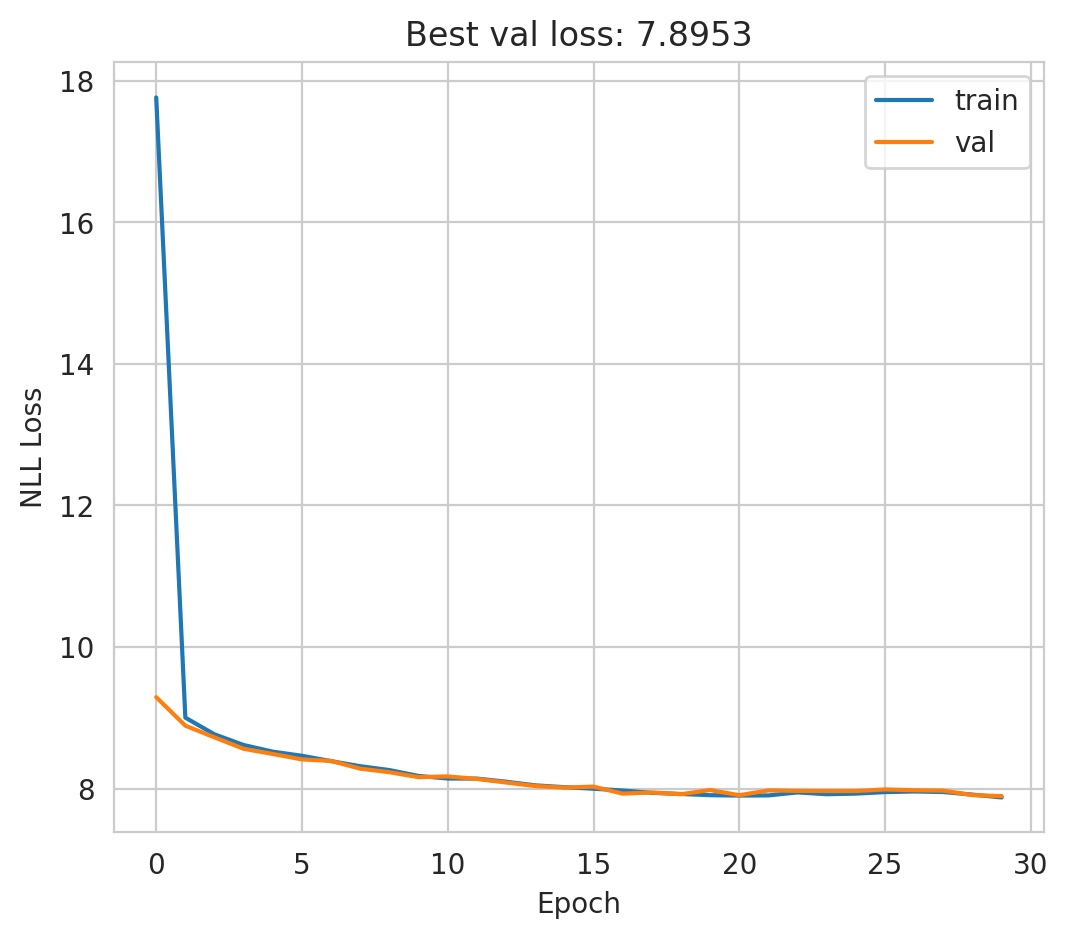

Epoch 30/30 | Train Loss: 7.8760 | Val Loss: 7.8953


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SketchRNNUncond(hidden_size=256, num_layers=1, num_mixtures=20).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = None

train_losses, val_losses = train_sketchrnn(
    model,
    train_loader,
    valid_loader,
    sketchrnn_loss,
    optimizer,
    scheduler,
    device,
    n_epochs=30
)


Now we can try to sample a sketch from our model!

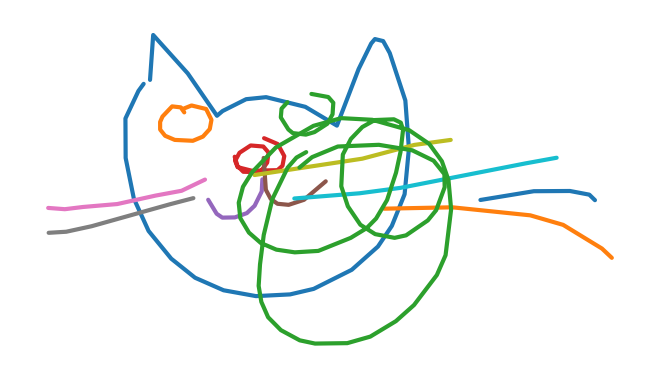

In [ ]:
sample = model.sample(max_len=200, temperature=0.3)
plot_sketch(sample)

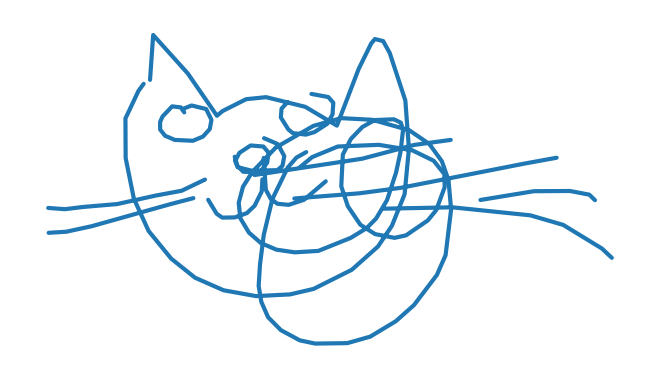

In [ ]:
animate_sketch(sample, delay=0.03)